In [2]:
import os
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
path = os.path.join( "..", "data", "processed", "accidents_clean.csv")
df = pd.read_csv(path)

In [3]:
df.drop(columns=['catv_regroup','equipements','age','col','trajet','age', 'atm',
                 'sexe','catu','place','motor','choc','obsm','manv','jour','mois','an','hrmn'], inplace=True)

In [4]:
# ---------------------------------
# 1. Maillage ~10 m (DEC = 4)
# ---------------------------------
DEC = 4                                 # ≈ 11 m lat × 7 m lon @46 °
df["lat10"] = (df["lat"]  * 10**DEC).round().astype(int)
df["lon10"] = (df["long"] * 10**DEC).round().astype(int)
df["cell_id"] = df["lat10"].astype(str) + "_" + df["lon10"].astype(str)

# ---------------------------------
# 2. Poids de gravité (plus progressifs)
# ---------------------------------
weights = {1: 1, 2: 4, 3: 12, 4: 25}    # à ajuster si besoin
df["score_unit"] = df["grav"].map(weights)   # ← Score pour chaque accident

# ---------------------------------
# 3. Fonction d’encodage de 'lum'
# ---------------------------------
def encode_lum(series):
    """1 si 3 est la plus fréquente (éclairage présent),
       2 si 4 ou 5 le sont (pas d’éclairage),
       0 si aucun 3-4-5 dans la maille."""
    counts = series.value_counts()
    for cat in counts.index:
        if cat == 3:
            return 1
        elif cat in (4, 5):
            return 2
    return 0

# ---------------------------------
# 4. Agrégation
# ---------------------------------
agg_dict = {
    # Variables agrégées comme avant
    "grav":  "median",
    "vma":   lambda s: s.mode().iat[0],
    "obs":   lambda s: s.mode().iat[0],
    "lum":   encode_lum,
    "agg":   lambda s: s.mode().iat[0],
    "int":   lambda s: s.mode().iat[0],
    "catr":  lambda s: s.mode().iat[0],
    "circ":  lambda s: s.mode().iat[0],
    "prof":  lambda s: s.mode().iat[0],
    "plan":  lambda s: s.mode().iat[0],
    "surf":  lambda s: s.mode().iat[0],
    "infra": lambda s: s.mode().iat[0],
    "situ":  lambda s: s.mode().iat[0],
    "dep":   lambda s: s.mode().iat[0],
    "com":   lambda s: s.mode().iat[0],

    # Compteur et score pondéré
    "lat":   "count",                 # nb_accidents (on renommera)
    "score_unit": "sum"               # somme des poids de gravité
}

grid_df = (
    df.groupby("cell_id", as_index=False)
      .agg(agg_dict)
      .rename(columns={
          "lat": "nb_accidents",
          "score_unit": "score"})     # score = Σ poids(grav)
)

In [5]:
bins = [0, 7, 14, 20, float('inf')]
labels = [1, 2, 3, 4]

grid_df['score_cat'] = pd.cut(grid_df['score'], bins=bins, labels=labels, right=False)
grid_df['score_cat'] = grid_df['score_cat'].astype(int)  

<Axes: title={'center': 'Répartition scores'}, xlabel='Score', ylabel='Nombre de cellules'>

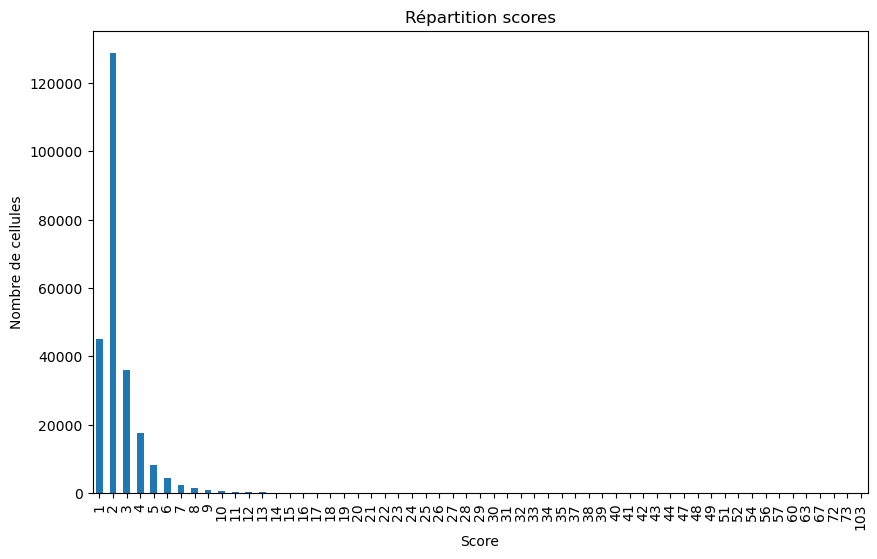

In [6]:
grid_df['nb_accidents'].value_counts().sort_index().plot(
    kind='bar',
    title='Répartition scores',
    xlabel='Score',
    ylabel='Nombre de cellules',
    figsize=(10, 6))

In [7]:
grid_df.to_csv("../data/processed/score_cat_preprocessed.csv", index=False)

<Axes: >

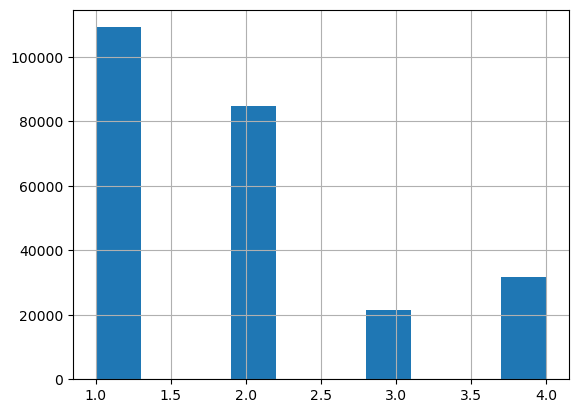

In [8]:
grid_df['score_cat'].hist()

<Axes: title={'center': 'Répartition scores'}, xlabel='Score', ylabel='Nombre de cellules'>

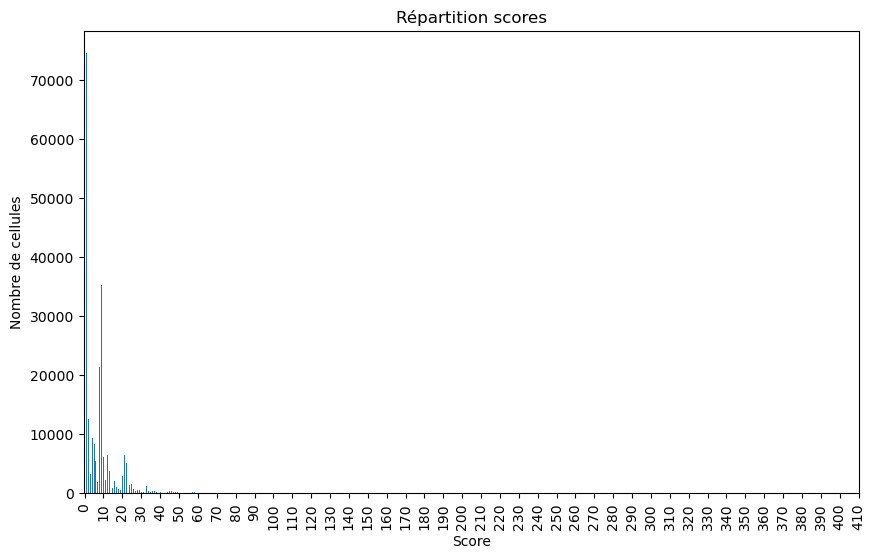

In [16]:
grid_df['score'].value_counts().sort_index().plot(
    kind='bar',
    title='Répartition scores',
    xlabel='Score',
    ylabel='Nombre de cellules',
    figsize=(10, 6),
    xticks=np.arange(0, grid_df['score'].max() + 1, 10))
# --------------------------------

In [12]:
grid_df['score'].value_counts().sort_values(ascending=True).head(30)

score
152    1
166    1
151    1
186    1
181    1
117    1
150    1
145    1
236    1
160    1
190    1
141    1
206    1
119    1
177    1
170    1
110    1
104    1
173    1
198    1
189    1
318    1
192    1
185    1
127    1
337    1
159    1
256    1
222    1
199    1
Name: count, dtype: int64